In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data=pd.read_csv('https://robertohincapie.com/data/permanencia_ingenierias.csv', sep=';', decimal=',', encoding='latin1')
data['DESERSIÓN']=data['DESERSIÓN'].replace({'SI':1, 'NO':0})

In [2]:
data

,Edad,SEXO,ALERTASROJAS,ALERTASNARANJAS,ALERTASACADEMICAS,ALERTASMANUALES,CAL.PSICOSOCIAL,CAL.FAMILIAR,CAL.SOCIECONOMICO,CAL.ACADEMICO,CRÉDITOS REPROBADOS,CRÉDITOS APROBADOS,CRÉDITOS CANCELADOS,CREDITOS INTENTADOS,PROMEDIO GLOBAL,ULTIMO ESTADO ACADÉMICO,APOYOS ECONÓMICO EN MATRICULA,APOYO INSTITUCIONAL,DESERSIÓN
0,21,M,14,17,0,0,10.31,28.21,22.37,10.61,3,65,0,68,3.832059,Estado académico normal,SI,SI,0
1,21,F,14,15,0,0,5.15,28.21,22.37,15.15,15,84,9,108,3.614646,Estado académico normal,SI,SI,0
2,19,F,13,19,0,0,8.25,28.21,21.05,15.15,6,8,3,17,2.855000,Advertencia académica,SI,SI,1
3,20,F,12,18,0,0,9.28,35.90,15.79,10.61,3,44,3,50,3.808936,Estado académico normal,SI,NO,0
4,20,F,12,14,0,0,10.31,17.95,23.68,4.55,0,149,4,153,4.202685,Estado académico normal,SI,SI,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909,21,M,3,11,0,0,0.00,12.82,11.84,4.55,6,93,19,118,3.572222,Estado académico normal,SI,SI,0
910,19,M,2,10,0,0,4.12,2.56,6.58,6.06,9,10,7,26,2.922105,Advertencia académica,SI,NO,1
911,19,M,2,13,0,0,2.06,15.38,5.26,7.58,3,36,6,45,3.700000,Estado académico normal,NO,SI,0
912,17,M,2,16,0,0,6.19,7.69,6.58,9.09,0,16,0,16,3.726875,Estado académico normal,SI,SI,0


In [3]:
data = pd.get_dummies(data, columns=['ULTIMO ESTADO ACADÉMICO'], drop_first=True, dtype=int)
data['DESERSIÓN']=data['DESERSIÓN'].replace({'NO':0, 'SI':1})
data['SEXO']=data['SEXO'].replace({'M':0, 'F':1,'N':2})
data['APOYOS ECONÓMICO EN MATRICULA']=data['APOYOS ECONÓMICO EN MATRICULA'].replace({'NO':0, 'SI':1})
data['APOYO INSTITUCIONAL']=data['APOYO INSTITUCIONAL'].replace({'NO':0, 'SI':1})
X=data.drop(['DESERSIÓN'], axis=1)
Y=data['DESERSIÓN']

In [4]:
data.var()

Edad                                                         4.0325
SEXO                                                       0.219726
ALERTASROJAS                                              14.466421
ALERTASNARANJAS                                           29.723263
ALERTASACADEMICAS                                               0.0
ALERTASMANUALES                                            0.003275
CAL.PSICOSOCIAL                                           18.140197
CAL.FAMILIAR                                              62.924618
CAL.SOCIECONOMICO                                          41.50726
CAL.ACADEMICO                                             27.667122
CRÉDITOS REPROBADOS                                       55.600269
CRÉDITOS APROBADOS                                      1341.748064
CRÉDITOS CANCELADOS                                      101.825824
CREDITOS INTENTADOS                                     1773.414023
PROMEDIO GLOBAL                                 

In [5]:
#Proceso de aplicación de PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
dataX=data.drop(['DESERSIÓN'], axis=1)
co=dataX.corr()
cols=dataX.columns
for i in range(len(cols)-1):
  for j in range(i+1, len(cols)):
    if(co.loc[cols[i],cols[j]]>=0.7):
      print(cols[i], cols[j],co.loc[cols[i],cols[j]])


ALERTASROJAS CAL.FAMILIAR 0.7450486785064868
ALERTASROJAS CAL.SOCIECONOMICO 0.7578955469943434
ALERTASNARANJAS CAL.ACADEMICO 0.7548178394397695
CRÉDITOS APROBADOS CREDITOS INTENTADOS 0.932123124917509


In [6]:
#A partir del análisis de correlación se eliminará: ALERTASROJAS, ALERTASNARANJAS, CREDITOS INTENTADOS
dataX=dataX.drop(['ALERTASROJAS', 'ALERTASNARANJAS', 'CREDITOS INTENTADOS'], axis=1)

[0.19408225 0.13641163 0.0798091  0.06456157 0.05720616 0.05624149
 0.05475776 0.05420977 0.05204916 0.04809577 0.0359938  0.03299142
 0.02841387 0.02659019 0.0241223  0.02146891 0.01911475 0.0138801
 0.        ]


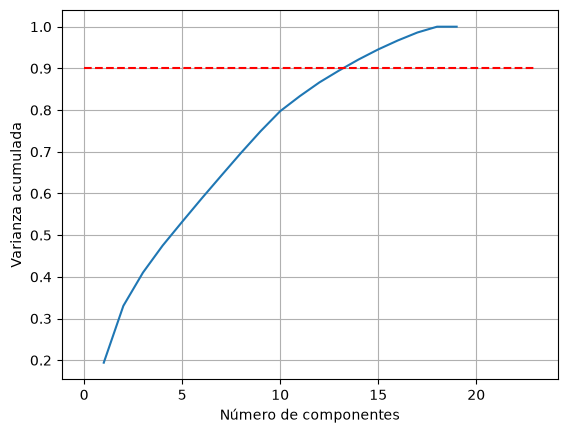

In [7]:
#print('Varianza de los datos:',data.var())
datos=StandardScaler().fit_transform(dataX)

pca=PCA(n_components=len(dataX.columns))
Y=pca.fit_transform(datos)
print(pca.explained_variance_ratio_)
plt.plot(range(1, len(dataX.columns)+1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.hlines(y=0.9, xmin=0, xmax=len(data.columns), linestyles='dashed', color='red')
plt.grid()
plt.show()

<Axes: >

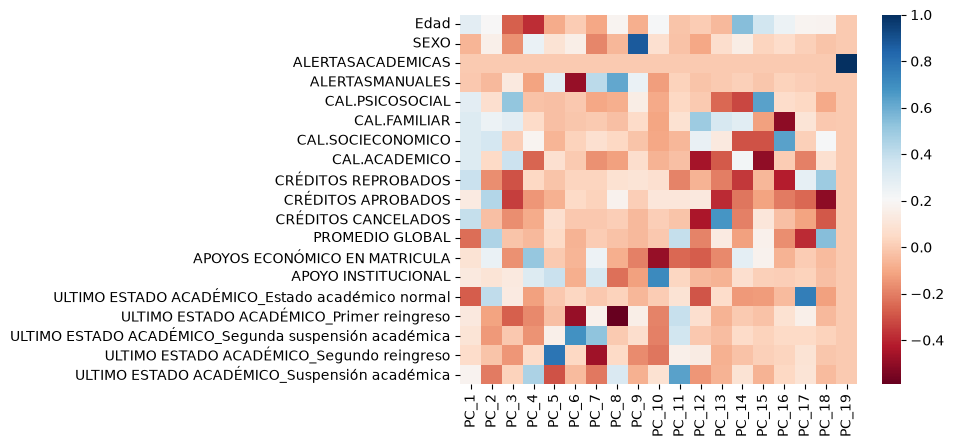

In [8]:
#print(pca.components_)
df=pd.DataFrame(pca.components_, columns=dataX.columns, index=['PC_'+str(i) for i in range(1,1+len(pca.components_))])
import seaborn as sns
sns.heatmap(df.T, cmap='RdBu') #, fmt='.2f', annot=True)

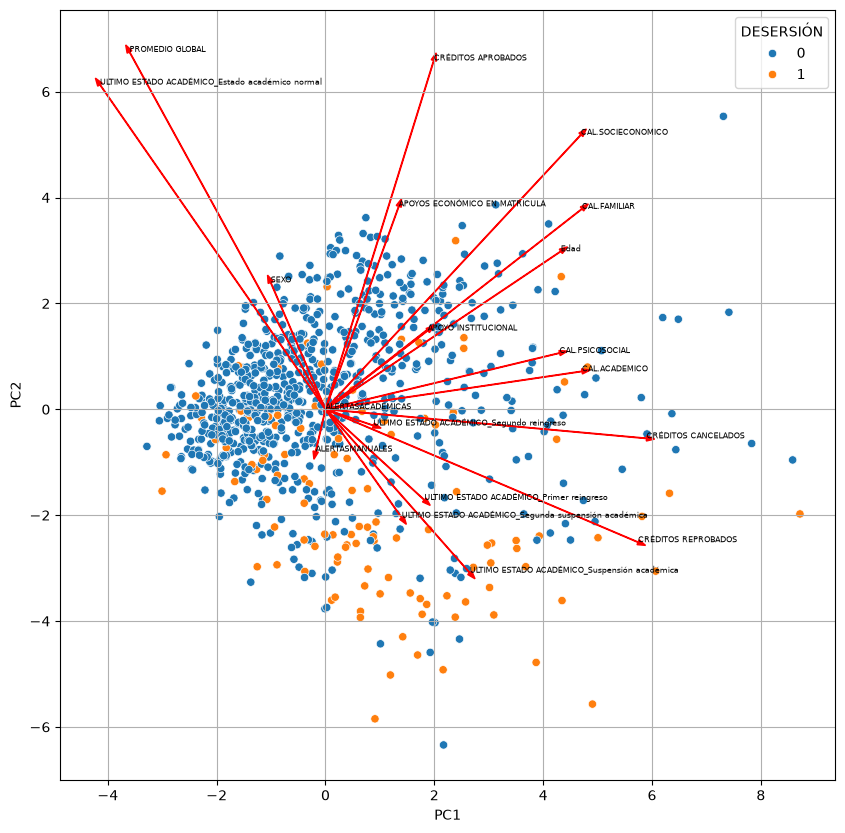

In [10]:
#Hagamos una representación en dos dimensiones de los datos
pca=PCA(n_components=2)
Y=pca.fit_transform(datos)
Y=pd.DataFrame(Y, columns=['PC1', 'PC2'])
Y['DESERSIÓN']=data['DESERSIÓN']
plt.figure(figsize=(10,10))
sns.scatterplot(x='PC1', y='PC2', hue='DESERSIÓN', data=Y)
plt.grid()

#Gráfico de las variables originales en los ejes nuevos:
K=15
for ri, name in zip(pca.components_.T, dataX.columns):
  plt.arrow(0, 0, ri[0]*K, ri[1]*K, color='r', width=0.01, head_width=0.1)
  plt.text(ri[0]*K, ri[1]*K, name, fontsize=6)


<Axes: >

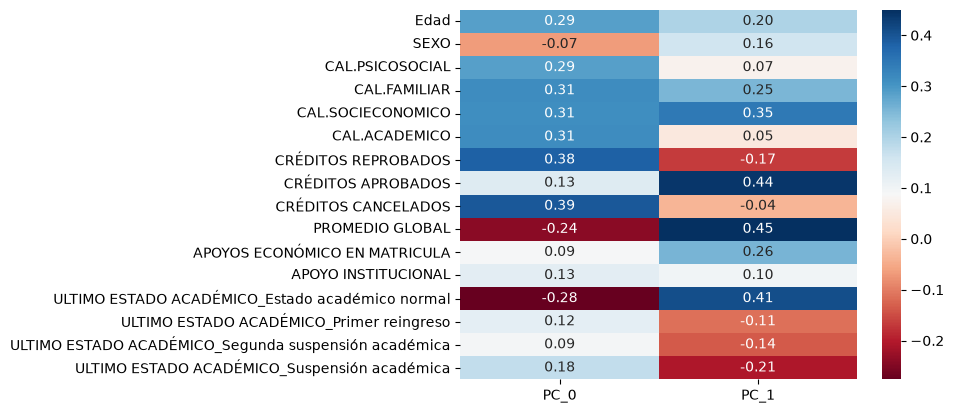

In [12]:
pca_comps=pd.DataFrame(pca.components_, columns=dataX.columns, index=['PC_'+str(i) for i in range(len(pca.components_))]).T
pca_comps['mag']=np.sqrt((pca_comps**2).sum(axis=1))
pca_comps=pca_comps[pca_comps['mag']>0.1]
pca_comps=pca_comps.drop(['mag'], axis=1)
sns.heatmap(pca_comps, cmap='RdBu', fmt='.2f', annot=True)